# Assignment: Clustering & Dimensionality Reduction

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [71]:

df = pd.read_csv("/content/iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [72]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Section A: K-Means Clustering & Elbow Method

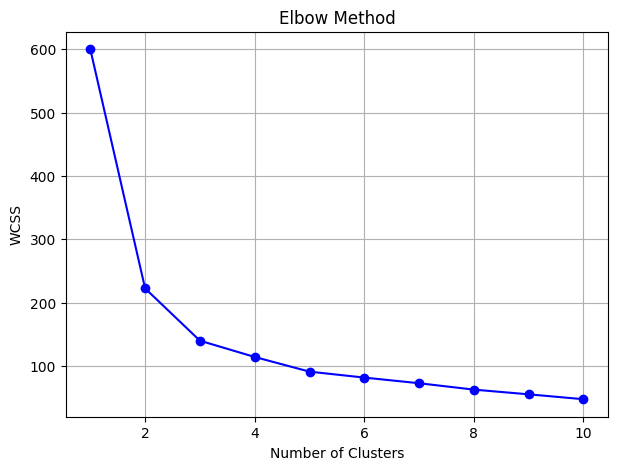

In [73]:
wcss = []

for k in range(1,11):
    km = KMeans(n_clusters=k,
                random_state=42,
                n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11),wcss,'bo-')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [74]:
kmeans = KMeans(n_clusters=3,
                random_state=42,
                n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df["KMeans"] = clusters

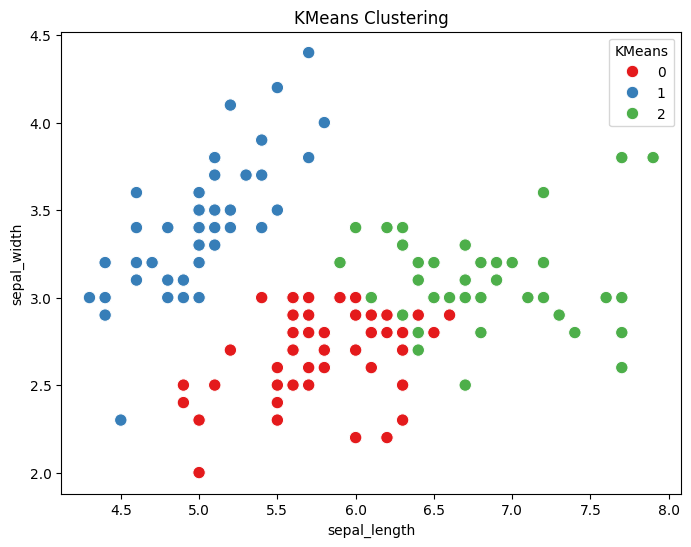

In [75]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df.iloc[:,0],
    y=df.iloc[:,1],
    hue=df["KMeans"],
    palette="Set1",
    s=80
)

plt.title("KMeans Clustering")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

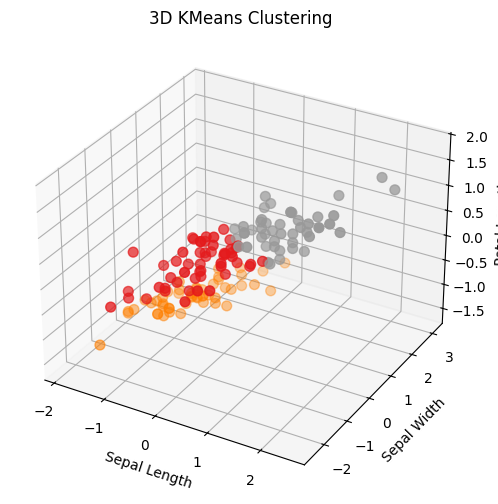

In [76]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    X_scaled[:,2],
    c=clusters,
    cmap='Set1',
    s=50
)

ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")

plt.title("3D KMeans Clustering")
plt.show()

# Section B: Principal Component Analysis (PCA)

In [77]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [78]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance:",
      np.sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.72962445 0.22850762]

Total Variance: 0.9581320720000166


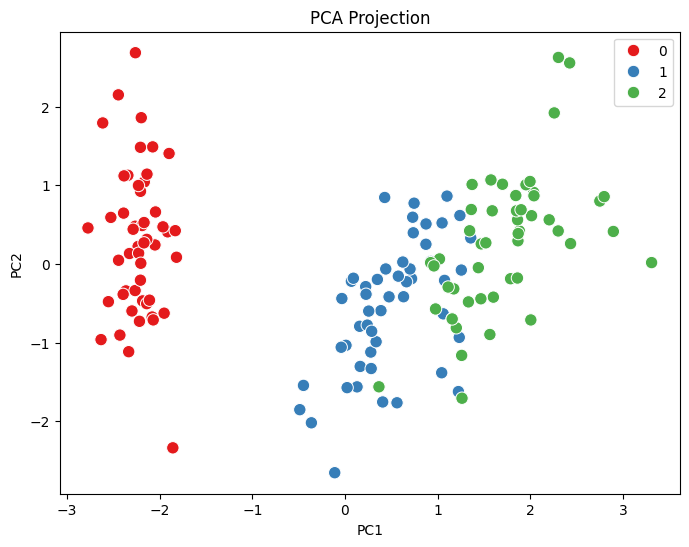

In [79]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette="Set1",
    s=80
)

plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

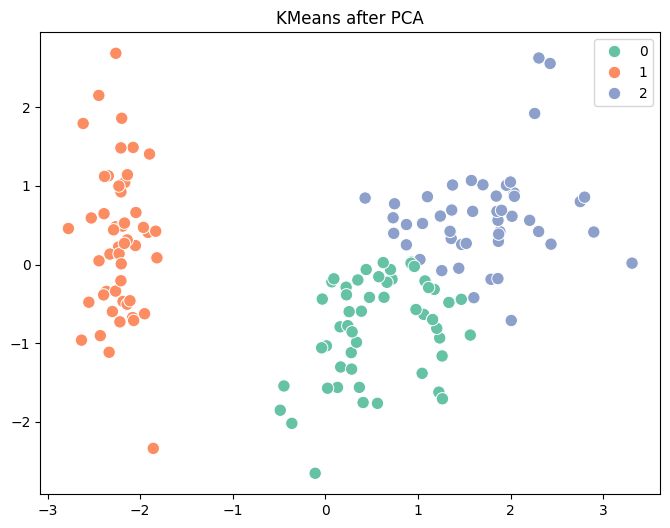

In [80]:
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_pca = kmeans_pca.fit_predict(X_pca)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=cluster_pca,
    palette="Set2",
    s=80
)

plt.title("KMeans after PCA")
plt.show()

In [81]:
score_original = silhouette_score(X_scaled, clusters)

score_pca = silhouette_score(X_pca, cluster_pca)

print("Original Data:",score_original)
print("PCA Data:",score_pca)

Original Data: 0.45994823920518635
PCA Data: 0.5091683341538228


# Section C: Hierarchical Clustering

In [82]:
hier = AgglomerativeClustering(n_clusters=3)

hier_clusters = hier.fit_predict(X_scaled)

df["Hierarchical"] = hier_clusters

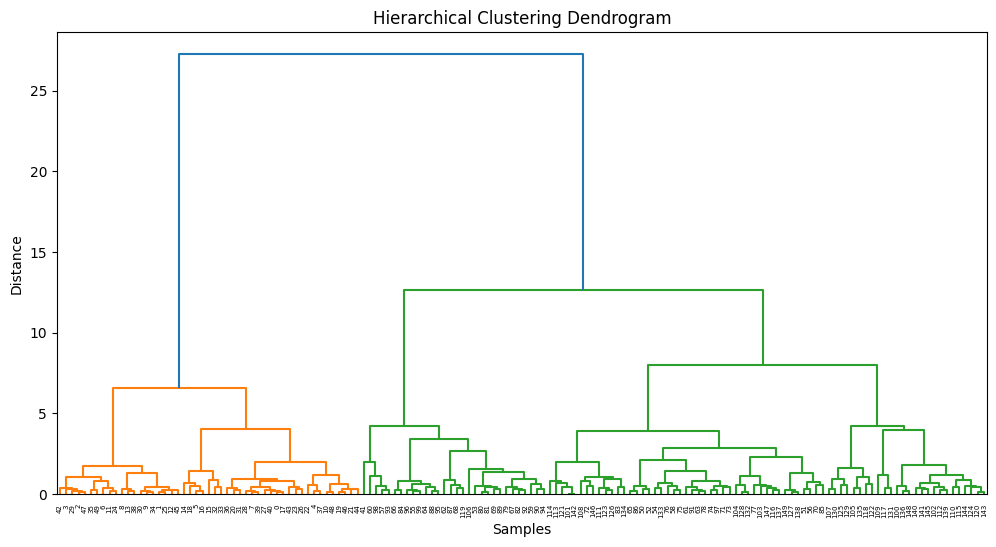

In [83]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

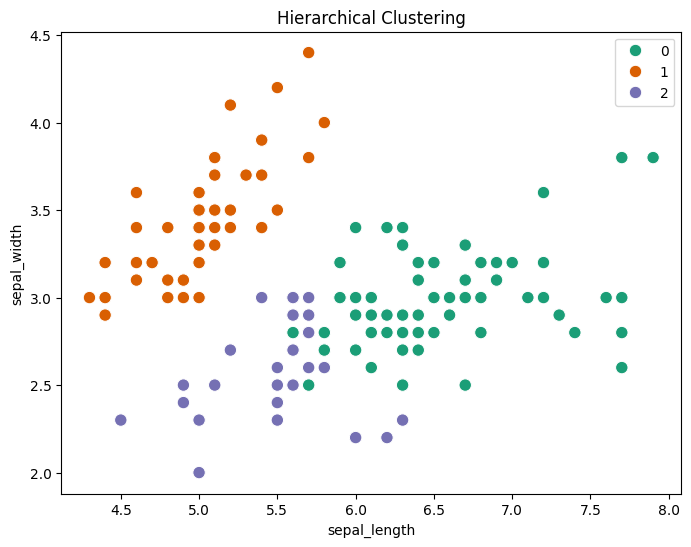

In [84]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df.iloc[:,0],
    y=df.iloc[:,1],
    hue=hier_clusters,
    palette="Dark2",
    s=80
)

plt.title("Hierarchical Clustering")
plt.show()

In [85]:
score_hier = silhouette_score(X_scaled,hier_clusters)

print("KMeans:",score_original)
print("Hierarchical:",score_hier)

KMeans: 0.45994823920518635
Hierarchical: 0.4466890410285909


# Section D: DBSCAN

In [86]:
dbscan = DBSCAN(
    eps=0.7,
    min_samples=5
)

db_clusters = dbscan.fit_predict(X_scaled)

df["DBSCAN"] = db_clusters

In [87]:
parameters = [
    (0.3,5),
    (0.5,5),
    (0.7,5),
    (1.0,5)
]

for eps,min_pts in parameters:

    model = DBSCAN(
        eps=eps,
        min_samples=min_pts
    )

    labels = model.fit_predict(X_scaled)

    print(
        "eps =",eps,
        "min_samples =",min_pts,
        "Clusters =",len(set(labels))-(-1 in labels),
        "Noise =",list(labels).count(-1)
    )

eps = 0.3 min_samples = 5 Clusters = 3 Noise = 120
eps = 0.5 min_samples = 5 Clusters = 2 Noise = 34
eps = 0.7 min_samples = 5 Clusters = 2 Noise = 6
eps = 1.0 min_samples = 5 Clusters = 2 Noise = 3


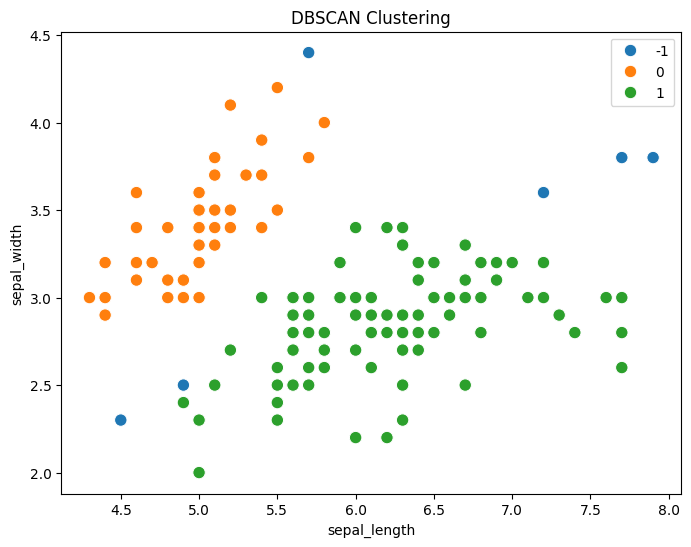

In [88]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df.iloc[:,0],
    y=df.iloc[:,1],
    hue=db_clusters,
    palette="tab10",
    s=80
)

plt.title("DBSCAN Clustering")
plt.show()

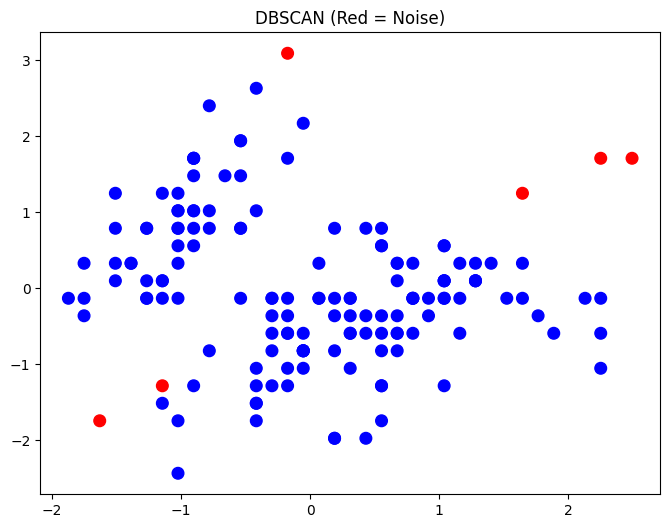

In [89]:
plt.figure(figsize=(8,6))

colors = []

for label in db_clusters:

    if label==-1:
        colors.append("red")
    else:
        colors.append("blue")

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=colors,
    s=70
)

plt.title("DBSCAN (Red = Noise)")
plt.show()

In [90]:
comparison = pd.DataFrame({
    "KMeans":clusters,
    "DBSCAN":db_clusters
})

comparison.head(15)

,KMeans,DBSCAN
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
5,1,0
6,1,0
7,1,0
8,1,0
9,1,0


In [91]:
print("""
Conclusion

1. Elbow Method selected K=3.

2. PCA reduced four features into two while preserving most information.

3. Hierarchical Clustering produced similar groups as KMeans.

4. DBSCAN successfully detected noise points and formed clusters based on density.

5. KMeans performed best for the Iris dataset because the classes are well-separated and approximately spherical.
""")


Conclusion

1. Elbow Method selected K=3.

2. PCA reduced four features into two while preserving most information.

3. Hierarchical Clustering produced similar groups as KMeans.

4. DBSCAN successfully detected noise points and formed clusters based on density.

5. KMeans performed best for the Iris dataset because the classes are well-separated and approximately spherical.

